# G-H Filtering


In [1]:
import kf_book.book_plots as book_plots
from kf_book.book_plots import plot_errorbars
import kf_book.gh_internal as gh
from kf_book.book_plots import figsize
import matplotlib.pyplot as plt

## Example 1

- **Assumed Error**: +- 8lbs 

- **Scale A**: 160 +-8 => 152-168 

- **Scale B**: 170 +-8 => 162-178

- **Actual Range**: 162-168


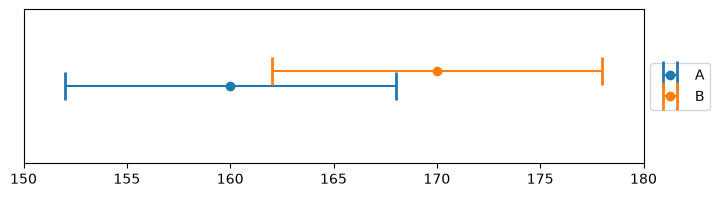

In [2]:
plot_errorbars([(160, 8, "A"), (170, 8, "B")], xlims=(150, 180))

## Example 2

- Scale A is **3x more accurate** than Scale B 

- **Scale A**: 160 +- 3 => 157-163

- **Scale B**: 170 +- 9 => 161-179

- **Actual Range**: 161-163

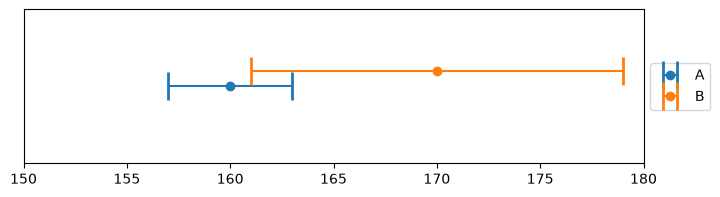

In [3]:
plot_errorbars([(160, 3, "A"), (170, 9, "B")], xlims=(150, 180))

## Example 3 
- **Scale A** accurate up to 1 lb. **Scale B** accurate up to 9 lbs. 

- **Scale A**: 160 +- 1 => 159-161 

- **Scale B**: 170 +- 9 => 161-179 

- **Actual Range**: 161

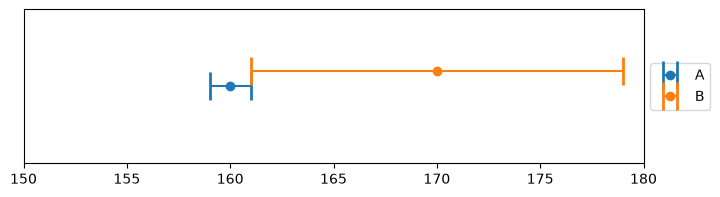

In [4]:
plot_errorbars([(160, 1, "A"), (170, 9, "B")], xlims=(150, 180))

## Averaging Experiments


In [5]:
import numpy as np

measurements = np.random.uniform(160, 170, size=10000)
mean = measurements.mean()
print(f"Average of measurements is {mean:.4f}")


Average of measurements is 165.0073


## Experiment 1 
- Measure weight once a day 

- **Readings**: 170, 161, 169 

- **Question**: Did we gain or lose weight? or is this all noisy measurements

- Scale is **accurate up to 10 lbs** 


### Hypothesis 1

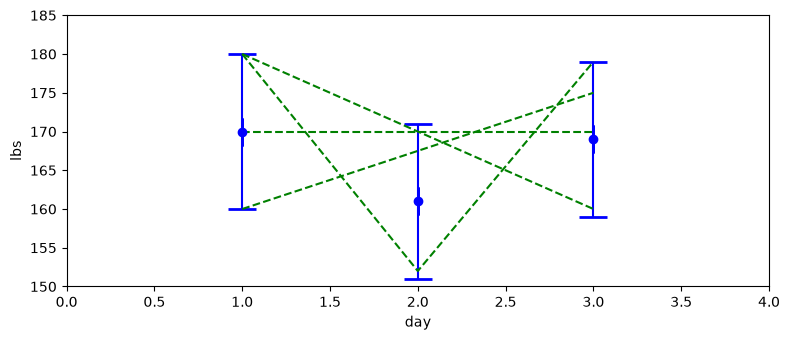

In [6]:
gh.plot_hypothesis1()

## Experiment 2 

- Measure weight once a day 

- **Readings**: 169, 170, 169, 171, 170, 171, 169, 170, 169, 170


### Hypothesis 2


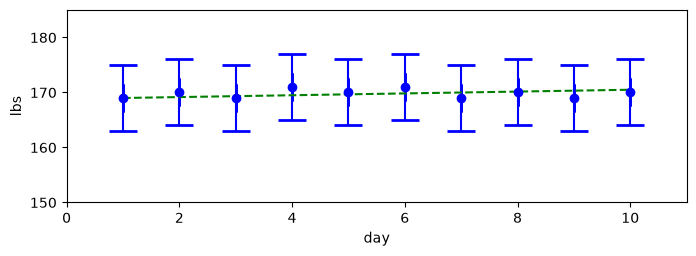

In [7]:
gh.plot_hypothesis2()

## Experiment 3 

- Measure weight once a day 
- **Readings**: 158.0, 164.2, 160.3, 159.9, 162.1, 164.6, 169.6, 167.4, 166.4, 171.0

### Hypothesis 3


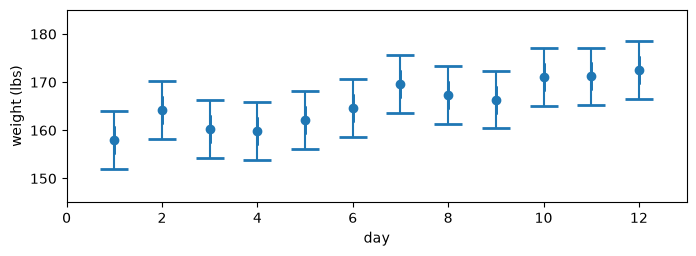

In [8]:
gh.plot_hypothesis3()

## Experiment 4 

- Measure weight once a day

### Hypothesis 4

- constant weight

- average the measurements


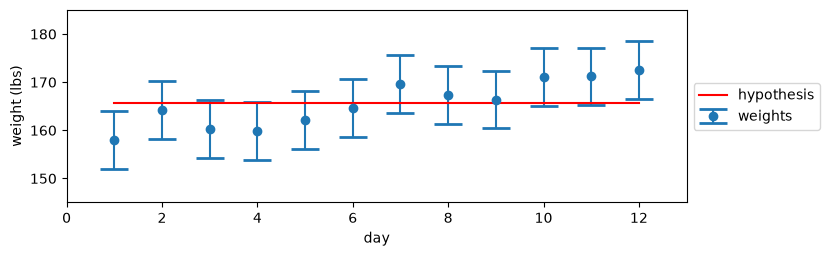

In [9]:
gh.plot_hypothesis4()

## Experiment 5

### Hypothesis 5

- weight gain

- least squares fit


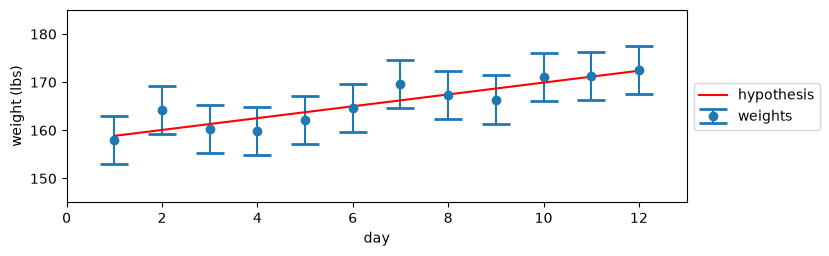

In [10]:
gh.plot_hypothesis5()

## Estimation Pipeline

### Estimatation - Prediction

- +1lb/day


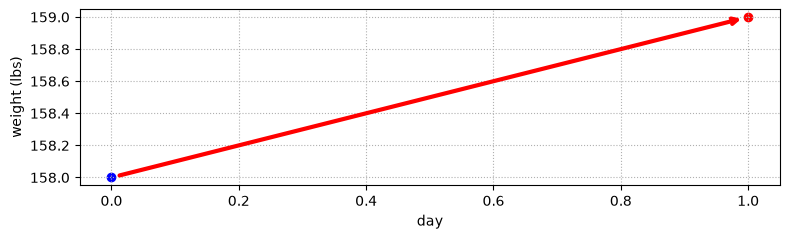

In [11]:
gh.plot_estimate_chart_1()

### Estimation - Prediction + Measurement


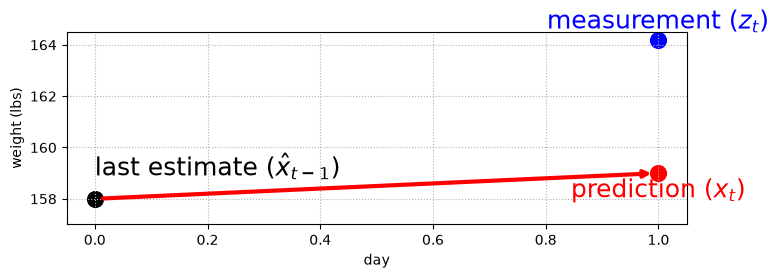

In [12]:
gh.plot_estimate_chart_2()

### Estimtation - Prediction + Measurement => New Estimate


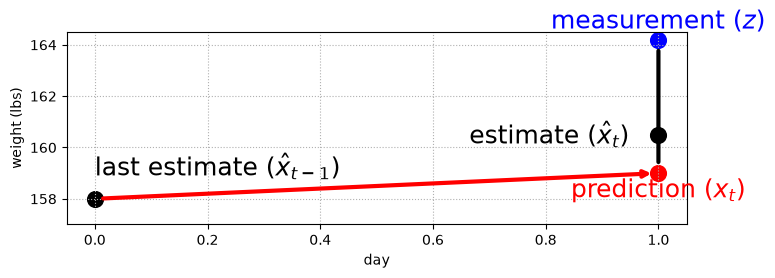

In [13]:
gh.plot_estimate_chart_3()

## Estimation Formula 
**estimate** = **prediction** + constant * (**measurement - prediction**)
- **residual** = (measurement - prediction)

## Experiment 1

- initial guess: 160lbs
- weight gain: 1lb/day


In [14]:
weights = [
    158.0,
    164.2,
    160.3,
    159.9,
    162.1,
    164.6,
    169.6,
    167.4,
    166.4,
    171.0,
    171.2,
    172.6,
]

time_step = 1.0  # day
scale_factor = 4.0 / 10


def predict_using_gain_guess(estimated_weight, gain_rate, do_print=False):
    # storage for the filtered results
    estimates, predictions = [estimated_weight], []

    # most filter literature uses 'z' for measurements
    for z in weights:
        # predict new position
        predicted_weight = estimated_weight + gain_rate * time_step

        # update filter
        estimated_weight = predicted_weight + scale_factor * (z - predicted_weight)

        # save and log
        estimates.append(estimated_weight)
        predictions.append(predicted_weight)
        if do_print:
            gh.print_results(estimates, predicted_weight, estimated_weight)

    return estimates, predictions


initial_estimate = 160.0
estimates, predictions = predict_using_gain_guess(
    estimated_weight=initial_estimate, gain_rate=1, do_print=True
)


previous estimate: 160.00, prediction: 161.00, estimate 159.80
previous estimate: 159.80, prediction: 160.80, estimate 162.16
previous estimate: 162.16, prediction: 163.16, estimate 162.02
previous estimate: 162.02, prediction: 163.02, estimate 161.77
previous estimate: 161.77, prediction: 162.77, estimate 162.50
previous estimate: 162.50, prediction: 163.50, estimate 163.94
previous estimate: 163.94, prediction: 164.94, estimate 166.80
previous estimate: 166.80, prediction: 167.80, estimate 167.64
previous estimate: 167.64, prediction: 168.64, estimate 167.75
previous estimate: 167.75, prediction: 168.75, estimate 169.65
previous estimate: 169.65, prediction: 170.65, estimate 170.87
previous estimate: 170.87, prediction: 171.87, estimate 172.16


weights: [158.0, 164.2, 160.3, 159.9, 162.1, 164.6, 169.6, 167.4, 166.4, 171.0, 171.2, 172.6]
predicted weights: [161.0, 160.8, 163.16, 163.016, 162.7696, 163.50176, 164.941056, 167.8046336, 168.64278016, 168.745668096, 170.6474008576, 171.86844051455998]
estimated weights: [160.0, 159.8, 162.16, 162.016, 161.7696, 162.50176, 163.941056, 166.8046336, 167.64278016, 167.745668096, 169.6474008576, 170.86844051455998, 172.16106430873597]


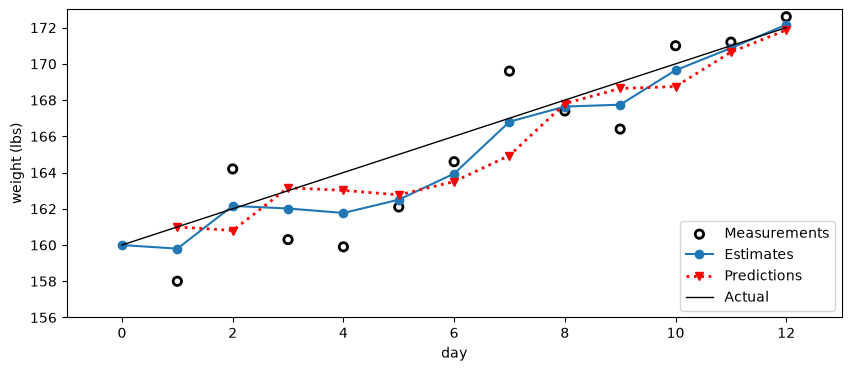

In [15]:
book_plots.set_figsize(10)
gh.plot_gh_results(weights, estimates, predictions, [160, 172])
print(f"weights: {weights}")
print(f"predicted weights: {predictions}")
print(f"estimated weights: {estimates}")

## Bad Guess

In [16]:
initial_estimate = 160.0
estimates, predictions = predict_using_gain_guess(
    estimated_weight=initial_estimate, gain_rate=-1, do_print=True
)

previous estimate: 160.00, prediction: 159.00, estimate 158.60
previous estimate: 158.60, prediction: 157.60, estimate 160.24
previous estimate: 160.24, prediction: 159.24, estimate 159.66
previous estimate: 159.66, prediction: 158.66, estimate 159.16
previous estimate: 159.16, prediction: 158.16, estimate 159.74
previous estimate: 159.74, prediction: 158.74, estimate 161.08
previous estimate: 161.08, prediction: 160.08, estimate 163.89
previous estimate: 163.89, prediction: 162.89, estimate 164.69
previous estimate: 164.69, prediction: 163.69, estimate 164.78
previous estimate: 164.78, prediction: 163.78, estimate 166.67
previous estimate: 166.67, prediction: 165.67, estimate 167.88
previous estimate: 167.88, prediction: 166.88, estimate 169.17


weights: [158.0, 164.2, 160.3, 159.9, 162.1, 164.6, 169.6, 167.4, 166.4, 171.0, 171.2, 172.6]
predicted weights: [159.0, 157.6, 159.23999999999998, 158.664, 158.1584, 158.73504, 160.08102399999999, 162.8886144, 163.69316864, 163.77590118400002, 165.66554071040002, 166.87932442624]
estimated weights: [160.0, 158.6, 160.23999999999998, 159.664, 159.1584, 159.73504, 161.08102399999999, 163.8886144, 164.69316864, 164.77590118400002, 166.66554071040002, 167.87932442624, 169.167594655744]


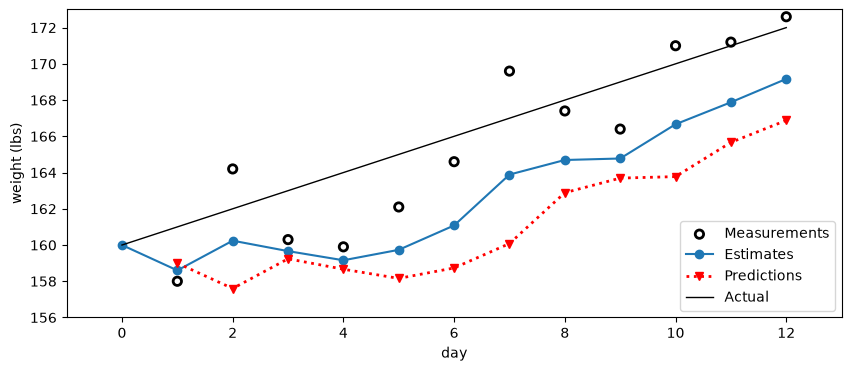

In [17]:
book_plots.set_figsize(10)
gh.plot_gh_results(weights, estimates, predictions, [160, 172])
print(f"weights: {weights}")
print(f"predicted weights: {predictions}")
print(f"estimated weights: {estimates}")

## Gain Estimation

- new gain = old gain + constant(measurement - prediction) / time_step 

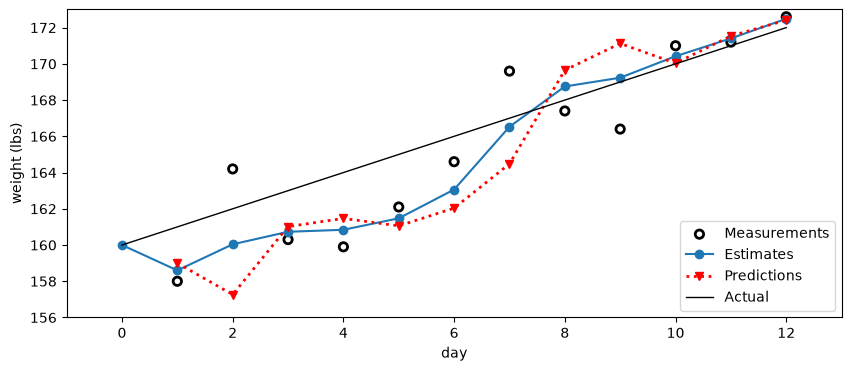

In [18]:
weight = 160.0  # initial guess
gain_rate = -1.0  # initial guess

time_step = 1.0
weight_scale = 4.0 / 10
gain_scale = 1.0 / 3
estimates = [weight]
predictions = []

for z in weights:
    # prediction step
    weight = weight + gain_rate * time_step
    gain_rate = gain_rate
    predictions.append(weight)

    # update step
    residual = z - weight

    gain_rate = gain_rate + gain_scale * (residual / time_step)
    weight = weight + weight_scale * residual

    estimates.append(weight)

gh.plot_gh_results(weights, estimates, predictions, [160, 172])

## G-H Filter 

- **residual equation**: measurement - prediction 

- **prediction equation**: prediction = initial_val/estimate_val + gain_rate * time_step 

- **gain update equation**: gain_rate = gain_rate + velocity_gain(h) * (residual / time_step)

- **estimate update equation**: estimate_val = prediction + position_gain(g) * residual

- **g**: position gain. controls how much you trust a new sensor measurement to adjust your current position 
- **h**: velocity gain. controls how much a new sensor measurement adjusts to your system's rate of change (how fast position or weight is changing over time)

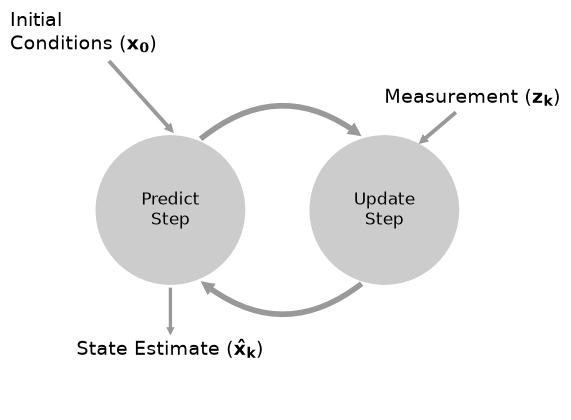

In [19]:
book_plots.predict_update_chart()

## Terminology 
- **System/Plant**: The object we want to estimate

- **State**: Current configuration or values of the system that is of interest

- **Measurement**: Measured value of the system

- **State Estimate(Estimate)**: The filter's estimate of the state

- **Hidden State(State)**: The actual value of the system. For the gh filter this is the actual value(g), and the actual rate of change(h)

- **Observed State(Measurement)**: The noisy value read from the sensor(measurement). 

- **Estimation Problem**: Derive an estimate of a hidden state via observable measurement

- **Process Model**: The mathematical model of the system 

- **Process Error(System Error)** - The error in the process model 

- **System Propagation**: Prediction Step. Use the process model to form a new state estimate

- **Measurement Update**: Update Step. 

- **Epoch**: One iteration of the system propagation and measurement update 



## Problem 1 - GH Filter

In [20]:
def g_h_filter(data, x0, dx, g, h, dt):
    result = []
    # init
    x_est = x0
    for z in data:
        # prediction
        x_pred = x_est + (dx * dt)
        dx = dx

        # update
        residual = z - x_pred
        dx = dx + h * (residual / dt)
        x_est = x_pred + g * residual

        result.append(x_est)

    return np.array(result)

measurements: [158.0, 164.2, 160.3, 159.9, 162.1, 164.6, 169.6, 167.4, 166.4, 171.0, 171.2, 172.6]
estimated values: [159.2        161.8        162.1        160.78       160.98533333
 163.31057778 168.10029037 169.69598183 168.20360386 169.1642501
 170.89234186 172.62868399]


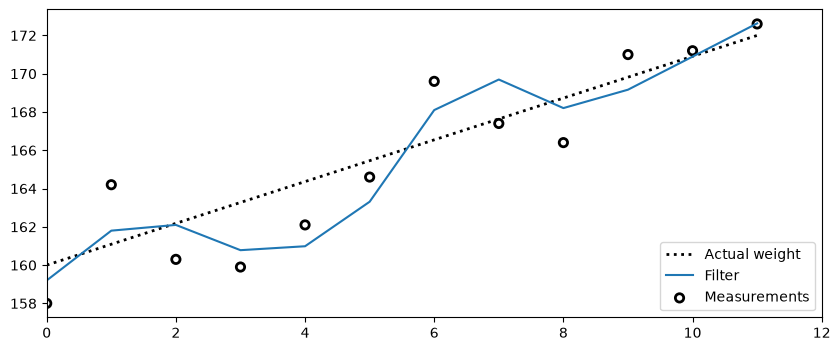

In [24]:
book_plots.plot_track([0, 11], [160, 172], label="Actual weight")
data = g_h_filter(data=weights, x0=160.0, dx=1.0, g=6.0 / 10, h=2.0 / 3, dt=1.0)
gh.plot_g_h_results(weights, data)
print(f"measurements: {weights}")
print(f"estimated values: {data}")

## Problem 2 - Measurement Function

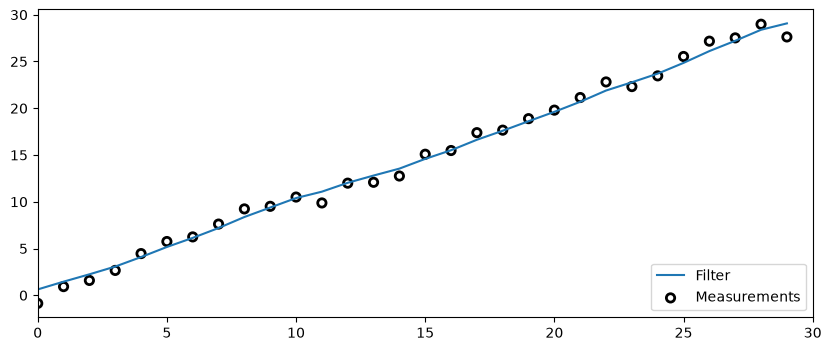

In [26]:
from numpy.random import randn


def gen_data(x0, dx, count, noise_factor):
    return [x0 + dx * i + randn() * noise_factor for i in range(count)]


measurements = gen_data(0, 1, 30, 1)
data = g_h_filter(data=measurements, x0=0.0, dx=1.0, dt=1.0, g=0.2, h=0.02)
gh.plot_g_h_results(measurements, data)

## Problem 3 - Bad Initial Conditions 

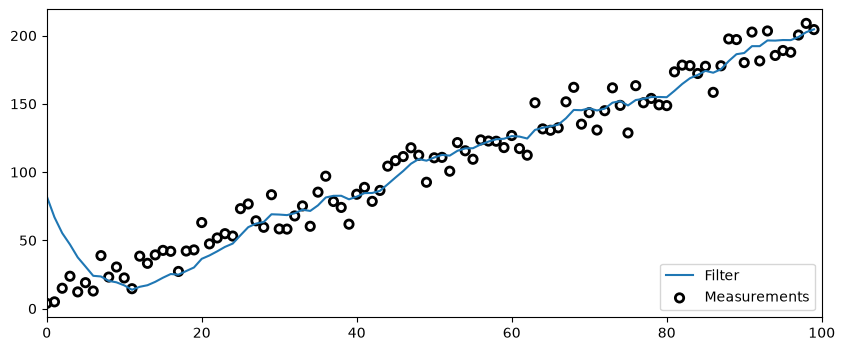

In [27]:
zs = gen_data(x0=5.0, dx=2.0, count=100, noise_factor=10)
data = g_h_filter(data=zs, x0=100.0, dx=2.0, dt=1.0, g=0.2, h=0.02)
gh.plot_g_h_results(measurements=zs, filtered_data=data)


## Train Problem

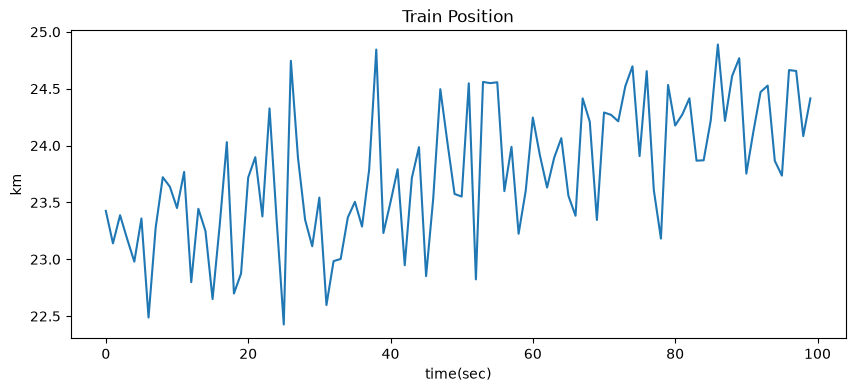

In [28]:
from numpy.random import randn


def compute_new_position(pos, vel, dt=1.0):
    """dt is the time delta in seconds."""
    return pos + (vel * dt)


def measure_position(pos):
    return pos + randn() * 500


def gen_train_data(pos, vel, count):
    zs = []
    for t in range(count):
        pos = compute_new_position(pos, vel)
        zs.append(measure_position(pos))
    return np.asarray(zs)


pos, vel = 23.0 * 1000, 15.0
zs = gen_train_data(pos, vel, 100)

plt.plot(zs / 1000.0)  # convert to km
book_plots.set_labels("Train Position", "time(sec)", "km")

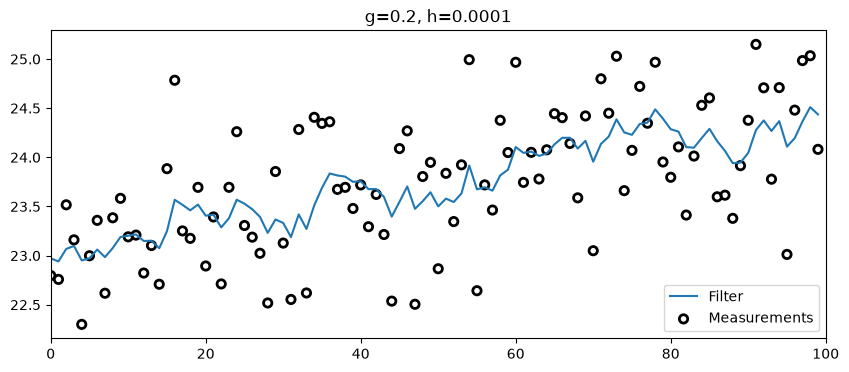

In [29]:
zs = gen_train_data(pos=pos, vel=15.0, count=100)
data = g_h_filter(data=zs, x0=pos, dx=15.0, dt=1.0, g=0.2, h=0.0001)
gh.plot_g_h_results(zs / 1000.0, data / 1000.0, "g=0.2, h=0.0001")


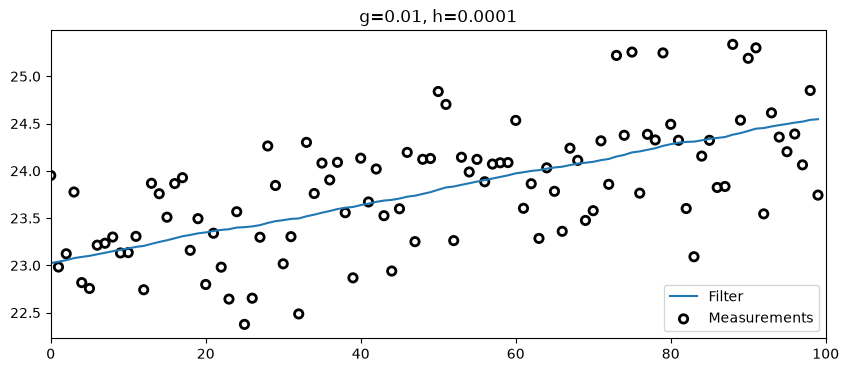

In [30]:
zs = gen_train_data(pos=pos, vel=15.0, count=100)
data = g_h_filter(data=zs, x0=pos, dx=15.0, dt=1.0, g=0.01, h=0.0001)
gh.plot_g_h_results(zs / 1000.0, data / 1000.0, "g=0.01, h=0.0001")
